<a href="https://colab.research.google.com/github/vixlima/neural-networks/blob/main/Implementa%C3%A7%C3%A3o_do_Backpropagation_em_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementação do Backpropagation em Python

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.special import expit

In [2]:
def cria_dataset(n_samples=100):
    X, _ = make_blobs(n_samples=n_samples, centers=[[0,1], [1,1], [0,0], [1,0]], cluster_std=0.1)

    y = np.array([
        1 if (x[0] > 0.5) ^ (x[1] > 0.5) else -1
        for x in X
    ])
    return X, y

In [3]:
def plot_dataset(X, y):
    plt.scatter(X[y == 1, 0], X[y == 1, 1], marker='o', alpha=0.5, label='Positivo (1)')
    plt.scatter(X[y == -1, 0], X[y == -1, 1], marker='x', alpha=0.5, label='Negativo (-1)')
    plt.legend()
    plt.show()

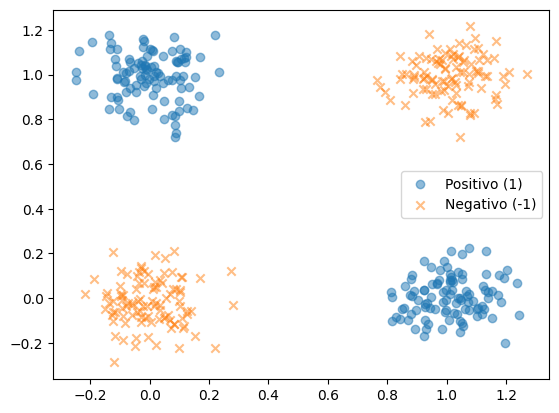

In [5]:
X, y = cria_dataset(400)
plot_dataset(X, y)

In [11]:
class SingleHiddenLayer(BaseEstimator, ClassifierMixin):
    def __init__(self, max_iter=1000, learning_rate=0.005, hidden_nodes=2):
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.hidden_nodes = hidden_nodes

    def include_bias(self, X):
        bias = np.ones((X.shape[0], 1))
        return np.concatenate((bias, X), axis=1)

    def forward(self, X_b):
        self.ph = X_b @ self.ih_w

        self.H = 2 * expit(self.ph) - 1

        self.H_b = self.include_bias(self.H)
        self.out_pre = self.H_b @ self.ho_w

        self.y_pred = 2 * expit(self.out_pre) - 1

    def backwards(self, X_b, y, y_pred):
        ho_delta = y - y_pred

        ho_grade = self.H_b.T @ ho_delta

        tanh_grade = 1 - np.square(self.H)

        ih_delta = (ho_delta @ self.ho_w[1:].T) * tanh_grade

        ih_grade = X_b.T @ ih_delta

        self.ho_w += self.learning_rate * ho_grade
        self.ih_w += self.learning_rate * ih_grade

    def fit(self, X, y):
        X_b = self.include_bias(X)
        y = y.reshape(-1, 1)

        self.ih_w = np.random.uniform(-1, 1, (X_b.shape[1], self.hidden_nodes))
        self.ho_w = np.random.uniform(-1, 1, (self.hidden_nodes + 1, 1))

        for _ in range(self.max_iter):
            self.forward(X_b)
            self.backwards(X_b, y, self.y_pred)

        return self

    def predict(self, X):
        X_b = self.include_bias(X)

        ph = X_b @ self.ih_w
        H = 2 * expit(ph) - 1
        H_b = self.include_bias(H)
        out_pre = H_b @ self.ho_w
        y_pred = 2 * expit(out_pre) - 1

        return np.where(y_pred > 0, 1, -1).flatten()

In [12]:
# Single Hidden Layer
clf_sh = SingleHiddenLayer(max_iter=3000, learning_rate=0.01, hidden_nodes=2)

In [13]:
# Fit
clf_sh.fit(X, y)

SingleHiddenLayer(learning_rate=0.01, max_iter=3000)

In [14]:
# Predict
y_pred_sh = clf_sh.predict(X)

In [15]:
# Acurácia
acuracia = accuracy_score(y, y_pred_sh)
print(f"Acurácia do classificador Single Hidden Layer: {acuracia * 100:.2f}%")

Acurácia do classificador Single Hidden Layer: 75.00%
